# Loan Default Prediction

In [1]:
# %pip install tensorflow

In [2]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

## 1. Load and Process Data

In [3]:
 # Load raw data
consumer_df, account_df, transaction_df = get_data()

# Filter consumers with no transaction or balance information
#consumer_df, account_df, transaction_df = filter_unknown(consumer_df, account_df, transaction_df)

Data successfully loaded and processed.


In [53]:
consumer_df[consumer_df['prism_consumer_id'] == '4007']

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
4007,4007,2021-11-01,745.0,NaN


In [5]:
transaction_df

,prism_consumer_id,prism_transaction_id,amount,credit_or_debit,posted_date,category
0,3023,0,0.05,CREDIT,2021-04-16,MISCELLANEOUS
1,3023,1,481.56,CREDIT,2021-04-30,LOAN
2,3023,2,0.05,CREDIT,2021-05-16,MISCELLANEOUS
3,3023,3,0.07,CREDIT,2021-06-16,MISCELLANEOUS
4,3023,4,0.06,CREDIT,2021-07-16,MISCELLANEOUS
...,...,...,...,...,...,...
6407316,10533,6405304,4.96,DEBIT,2022-03-11,BILLS_UTILITIES
6407317,10533,6405305,63.48,DEBIT,2022-03-30,LOAN
6407318,10533,6405306,53.99,DEBIT,2022-03-30,LOAN
6407319,10533,6405307,175.98,DEBIT,2022-03-31,LOAN


### Scoring Exclusion
Filtering out consumers with thin files





In [6]:
enriched_df = identify_thin_files(
    transaction_df, 
    account_df, 
    consumer_df,
    min_transactions=3,
    min_transaction_months=1,
    min_balance_records=1
)

# Analyze thin file characteristics
analyze_thin_files(enriched_df)

# Filter out thin files before feature creation
thick_file_consumers = enriched_df[~enriched_df['is_thin_file']]['prism_consumer_id']

# Filter your dataframes
filtered_consumer_df = consumer_df[consumer_df['prism_consumer_id'].isin(thick_file_consumers)]
filtered_account_df = account_df[account_df['prism_consumer_id'].isin(thick_file_consumers)]
filtered_transaction_df = transaction_df[transaction_df['prism_consumer_id'].isin(thick_file_consumers)]

Data Sufficiency Analysis
--------------------------------------------------

Overall Thin File Rate:
is_thin_file
False    0.826
True     0.174
Name: proportion, dtype: float64

Insufficiency Reasons:

insufficient_transactions:
insufficient_transactions
False    0.948
True     0.052
Name: proportion, dtype: float64

insufficient_transaction_history:
insufficient_transaction_history
False    0.966
True     0.034
Name: proportion, dtype: float64

insufficient_balance_records:
insufficient_balance_records
False    0.867
True     0.133
Name: proportion, dtype: float64

Default Rates Comparison:
Thin Files Default Rate: 0.072
Thick Files Default Rate: 0.086

Data Metrics Distribution:

total_transactions:
count    15000.00
mean       427.15
std        397.57
min          0.00
25%        154.00
50%        337.00
75%        589.00
max       8478.00
Name: total_transactions, dtype: float64

months_with_transactions:
count    15000.00
mean         5.97
std          2.62
min          0.00
25% 

In [7]:
analyze_exclusion_impact(consumer_df, filtered_consumer_df)

Exclusion Impact Analysis
--------------------------------------------------

Sample Size Impact:
Original samples: 15000
Filtered samples: 12392
Reduction: 17.4%

Default Rate Impact:
Original default rate: 0.084
Filtered default rate: 0.086

Credit Score Distribution:
Original:
count    15000.00
mean       661.19
std         76.53
min        353.00
25%        618.00
50%        661.00
75%        712.00
max        850.00
Name: credit_score, dtype: float64

Filtered:
count    12392.00
mean       661.38
std         79.33
min        353.00
25%        614.00
50%        661.00
75%        716.00
max        850.00
Name: credit_score, dtype: float64


In [8]:
# replace the original dataframes with the filtered dataframes
consumer_df = filtered_consumer_df
account_df = filtered_account_df
transaction_df = filtered_transaction_df

# display filtered dataframes
consumer_df

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0
...,...,...,...,...
14991,14991,2022-01-26,667.0,NaN
14992,14992,2022-03-14,709.0,NaN
14994,14994,2022-01-15,616.0,NaN
14996,14996,2022-01-15,625.0,NaN


### Feature Creation

In [9]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time_fix,
    balance_over_time,
    credit_score
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, consumer_df, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 9
- New features (1): credit_score
- Updated features: 8
- Unchanged feature creation functions: 0 (using cached results)

Executing features...
- Running credit_score...
- Running average_transaction_amount...
- Running net_monthly_cash_flow...
- Running average_account_balance...
- Running time_based_average_transaction_amounts...


/Users/qianjin/Desktop/DSC180AB/180B/credit_scoring/src/scripts/features.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['year'] = transaction_df['posted_date'].dt.year
/Users/qianjin/Desktop/DSC180AB/180B/credit_scoring/src/scripts/features.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['month'] = transaction_df['posted_date'].dt.month
/Users/qianjin/Desktop/DSC180AB/180B/credit_scoring/src/scripts/features.py:83: SettingWithCopyWarning: 
A value is trying to be set

- Running descriptive_stats_by_category...
- Running outflow_stats...
- Running outflow_over_time_fix...
- Running balance_over_time...

Total Created Features:  267


## 2 Split Data

In [10]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 7447
No validation set created.
Test set size: 2483


## 3. All Model Performances

In [11]:
summary_table = evaluate_feature_model_combinations(train_df, test_df, all_feature_columns)

Evaluating: Feature Selection = all_features, Model = xgboost
Evaluating: Feature Selection = all_features, Model = gradient_boosting
Evaluating: Feature Selection = all_features, Model = random_forest
Evaluating: Feature Selection = all_features, Model = logistic
Evaluating: Feature Selection = mutual_info, Model = xgboost
Evaluating: Feature Selection = mutual_info, Model = gradient_boosting
Evaluating: Feature Selection = mutual_info, Model = random_forest
Evaluating: Feature Selection = mutual_info, Model = logistic
Evaluating: Feature Selection = random_forest, Model = xgboost
Evaluating: Feature Selection = random_forest, Model = gradient_boosting
Evaluating: Feature Selection = random_forest, Model = random_forest
Evaluating: Feature Selection = random_forest, Model = logistic
Evaluating: Feature Selection = xgboost, Model = xgboost
Evaluating: Feature Selection = xgboost, Model = gradient_boosting
Evaluating: Feature Selection = xgboost, Model = random_forest
Evaluating: Featur

In [12]:
summary_table

,Feature Selection,Model,Test Accuracy,Test Balanced Accuracy,Test ROC AUC
0,all_features,xgboost,0.80,0.73,0.82
1,all_features,gradient_boosting,0.92,0.54,0.82
2,all_features,random_forest,0.92,0.52,0.80
3,all_features,logistic,0.73,0.73,0.78
4,mutual_info,xgboost,0.79,0.74,0.82
5,mutual_info,gradient_boosting,0.92,0.55,0.82
6,mutual_info,random_forest,0.92,0.53,0.81
7,mutual_info,logistic,0.72,0.72,0.80
8,random_forest,xgboost,0.79,0.75,0.83
9,random_forest,gradient_boosting,0.92,0.55,0.82


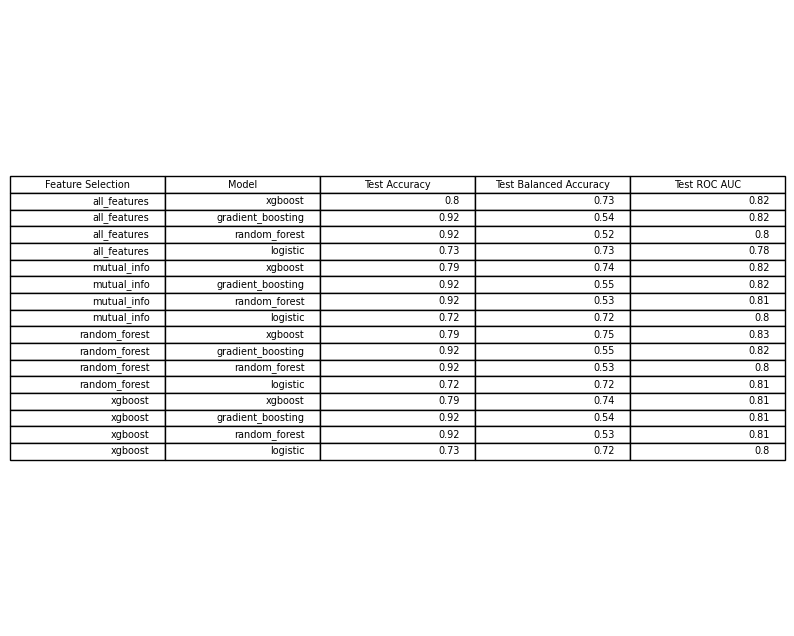

In [13]:
# Set up the matplotlib figure and axis
fig, ax = plt.subplots(figsize=(len(summary_table.columns) * 2, len(summary_table) * 0.5))
ax.axis('tight')
ax.axis('off')

# Create the table plot from the DataFrame
table = ax.table(cellText=summary_table.values, colLabels=summary_table.columns, loc='center')
 
# Save the figure as an image file
plt.show()

## 4. Individual Model Training

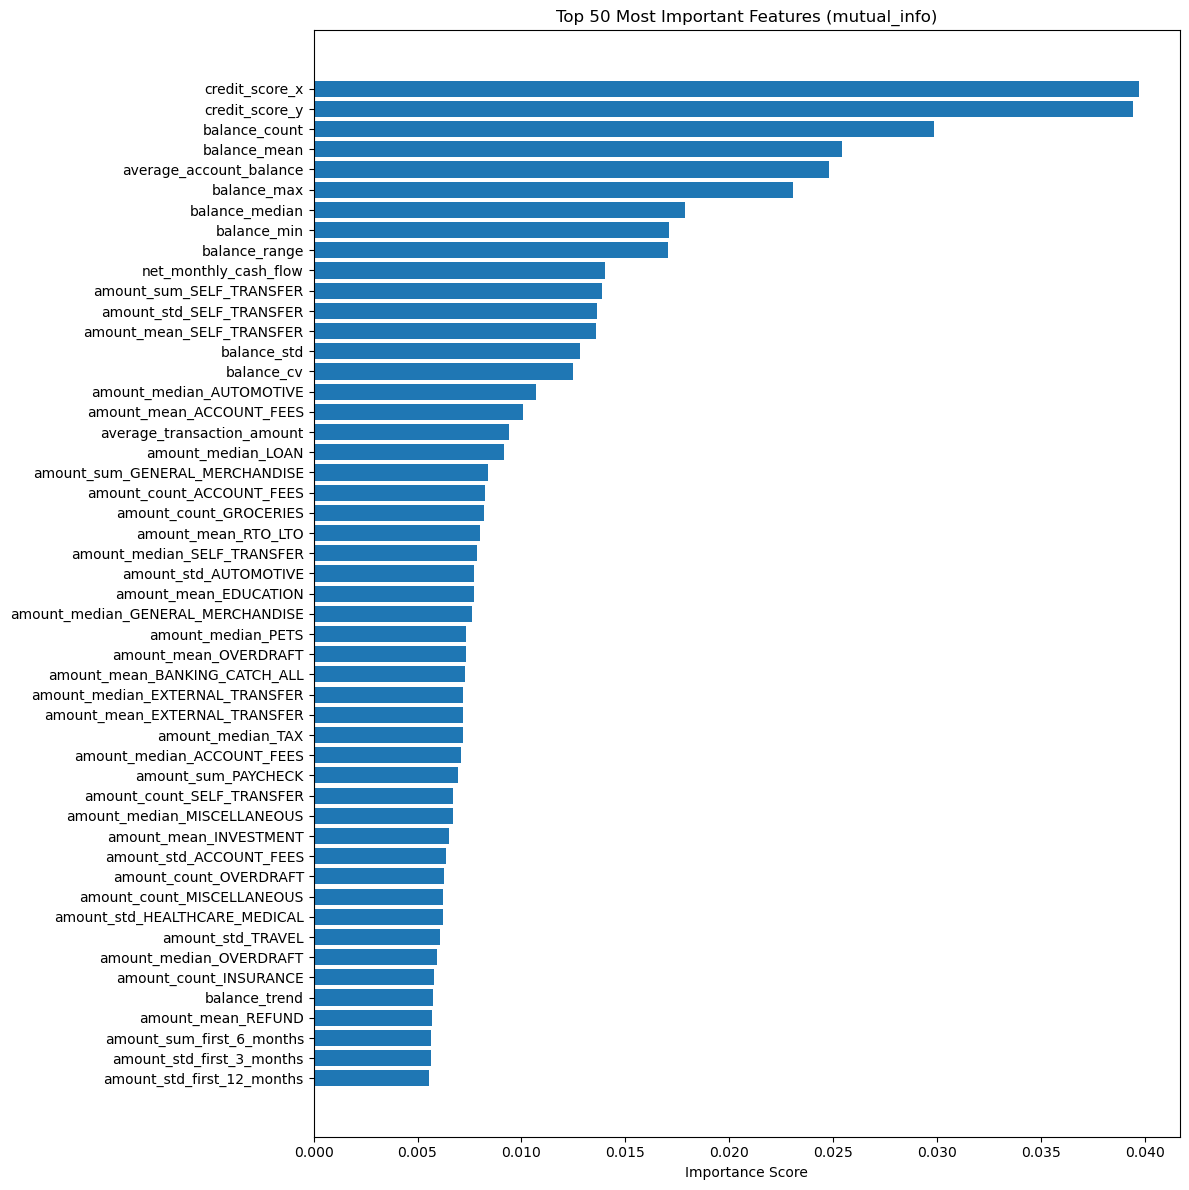

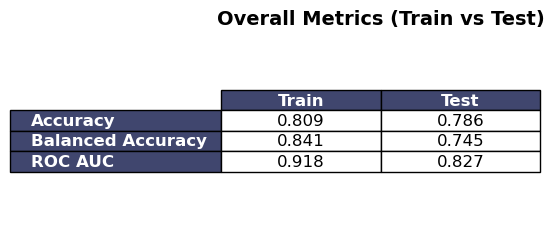


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.985717  0.802355  0.884634  6795.000000  0.966880  0.794208  0.872079  2279.000000
1.0           0.299061  0.878834  0.446262   652.000000  0.232406  0.696078  0.348466   204.000000
accuracy      0.809051  0.809051  0.809051     0.809051  0.786146  0.786146  0.786146     0.786146
macro avg     0.642389  0.840595  0.665448  7447.000000  0.599643  0.745143  0.610273  2483.000000
weighted avg  0.925599  0.809051  0.846254  7447.000000  0.906537  0.786146  0.829060  2483.000000


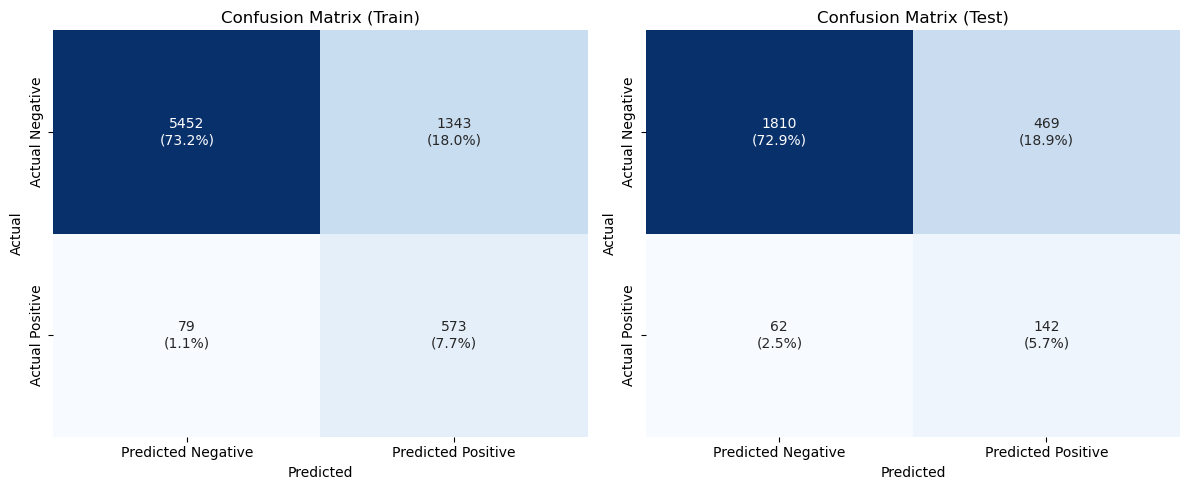

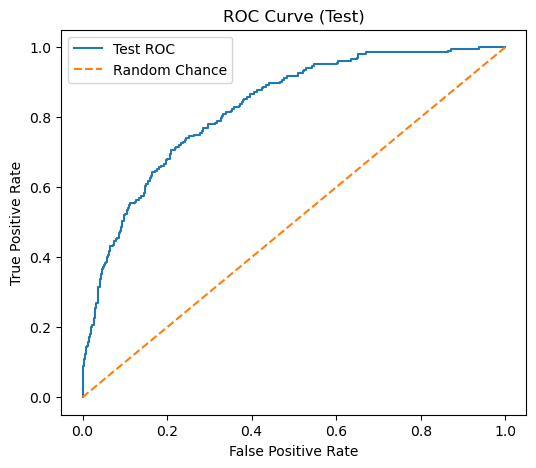

In [14]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=50)

# Initialize and train model with all features
X_train, X_train_scaled, model, scaler = train_model(train_df, feature_columns, "xgboost")
X_test, X_test_scaled, y_test, y_pred_test, results = predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)


Model Architecture:


/Users/qianjin/anaconda3/envs/creditrisk/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)


Class Distribution:
DQ_TARGET
0.0    0.912448
1.0    0.087552
Name: proportion, dtype: float64

Class Weights:
{0: 0.5479764532744665, 1: 5.710889570552148}
Epoch 1/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - AUC: 0.6785 - accuracy: 0.6678 - loss: 0.6821 - val_AUC: 0.7665 - val_accuracy: 0.7013 - val_loss: 0.5571
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - AUC: 0.7750 - accuracy: 0.6718 - loss: 0.5948 - val_AUC: 0.7701 - val_accuracy: 0.7121 - val_loss: 0.5515
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - AUC: 0.7747 - accuracy: 0.6780 - loss: 0.5949 - val_AUC: 0.7718 - val_accuracy: 0.7060 - val_loss: 0.5594
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - AUC: 0.7872 - accuracy: 0.6881 - loss: 0.5815 - val_AUC: 0.7746 - val_accuracy: 0.7101 - val_loss: 0.5482
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - AUC: 0.7978 - accuracy: 0.6973 - loss: 0.5661 - val_AUC: 0.7759 - val_accuracy: 0.7181 - val_loss: 0.5494
Epoch 6/100
187/187 ━━━━━━━━━

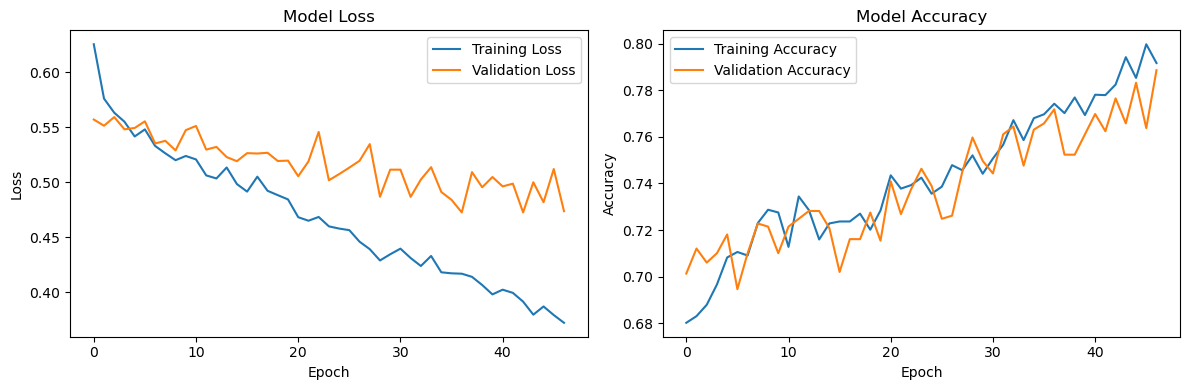


Input Data Statistics:
Mean: -2.4673875583129033e-17
Std: 1.0
Min: -26.931858510311756
Max: 86.17061441605979

Prediction Distribution:
0    0.759565
1    0.240435
Name: proportion, dtype: float64

Prediction Distribution:
0    0.741104
1    0.258896
Name: proportion, dtype: float64


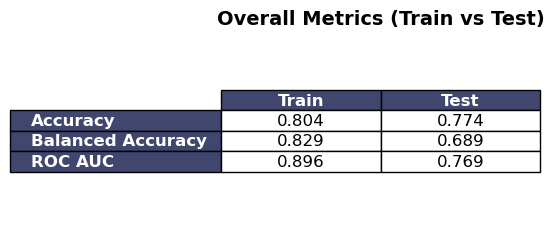


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.983330  0.798675  0.881436  6795.000000  0.955461  0.790698  0.865306  2279.000000
1.0           0.290456  0.858896  0.434109   652.000000  0.201005  0.588235  0.299625   204.000000
accuracy      0.803948  0.803948  0.803948     0.803948  0.774064  0.774064  0.774064     0.774064
macro avg     0.636893  0.828786  0.657772  7447.000000  0.578233  0.689466  0.582466  2483.000000
weighted avg  0.922668  0.803948  0.842271  7447.000000  0.893476  0.774064  0.818831  2483.000000


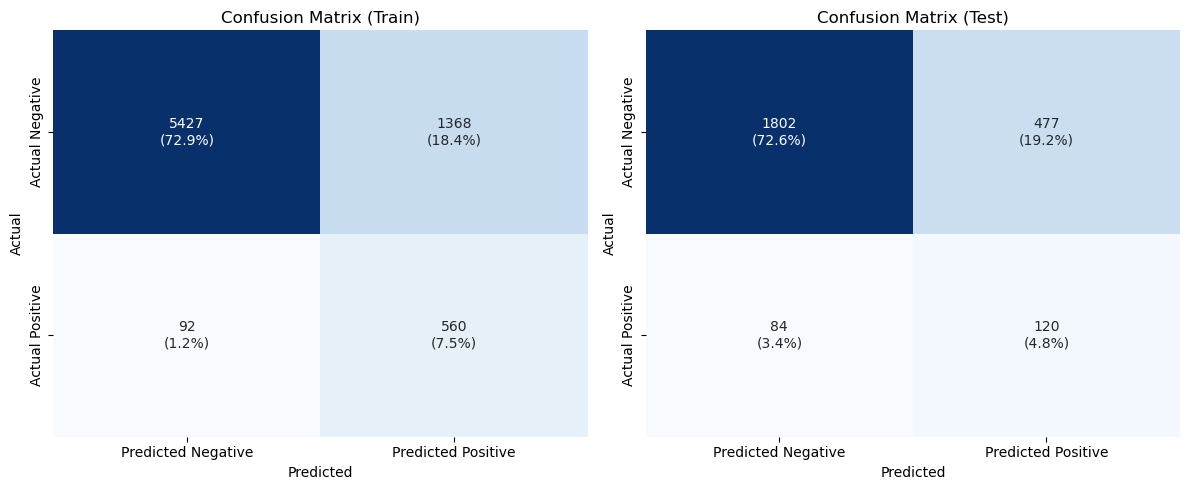

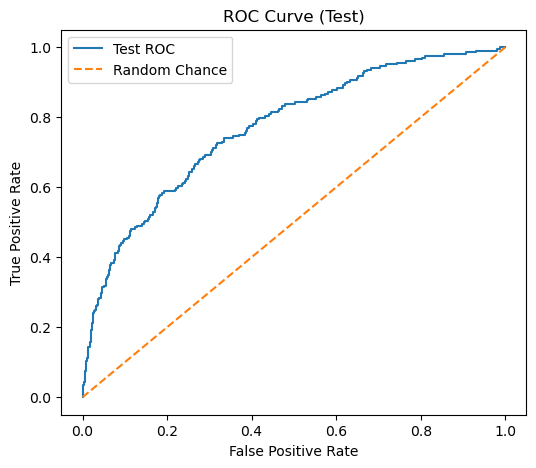

In [15]:
# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Initialize and train model with selected features
X_train, X_train_scaled, nn_model, scaler = train_model(train_df, feature_columns, "neural_network")

# Check the scale of the input data
print("\nInput Data Statistics:")
print("Mean:", X_train_scaled.mean())
print("Std:", X_train_scaled.std())
print("Min:", X_train_scaled.min())
print("Max:", X_train_scaled.max())

# Analyze model performance
results = predict_and_analyze_model(
    nn_model, 
    scaler, 
    train_df, 
    test_df, 
    feature_columns,
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True,
    show_roc_curve=True
)

## 5. SHAP

- Most impactful features for the model overall (according to SHAP):

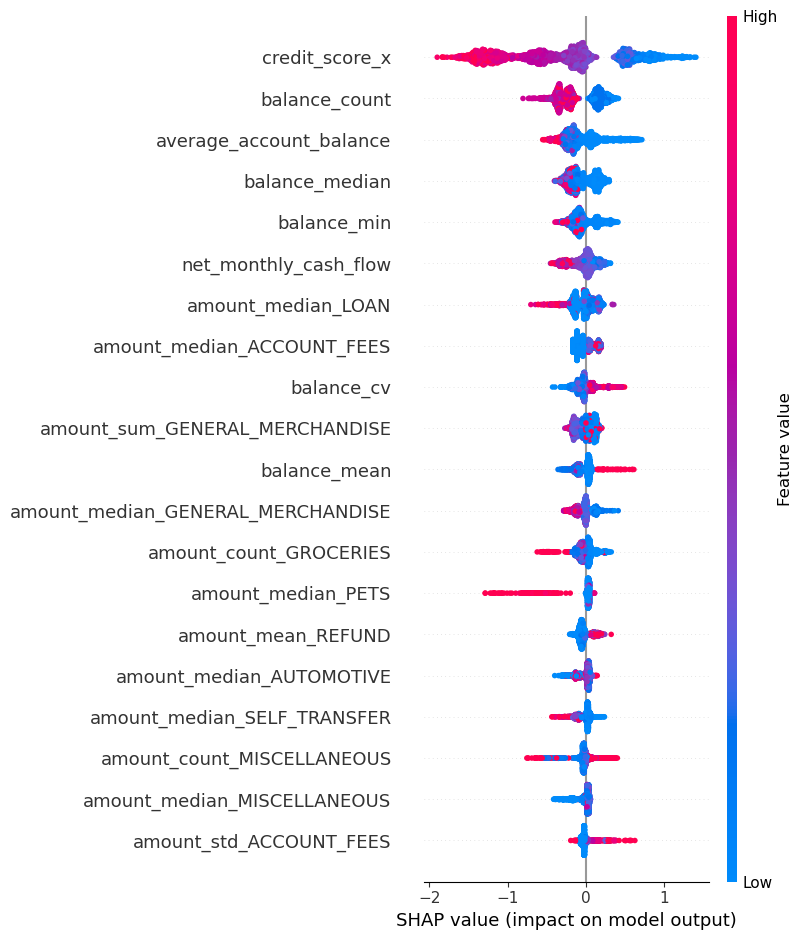

In [16]:
scaled_feats, explainer, shap_values = shap_plots(model, X_test, X_test_scaled)

- Waterfall plot for an individual person:
    - Person here was predicted as not defaulting

In [17]:
y_pred_test[0]

0

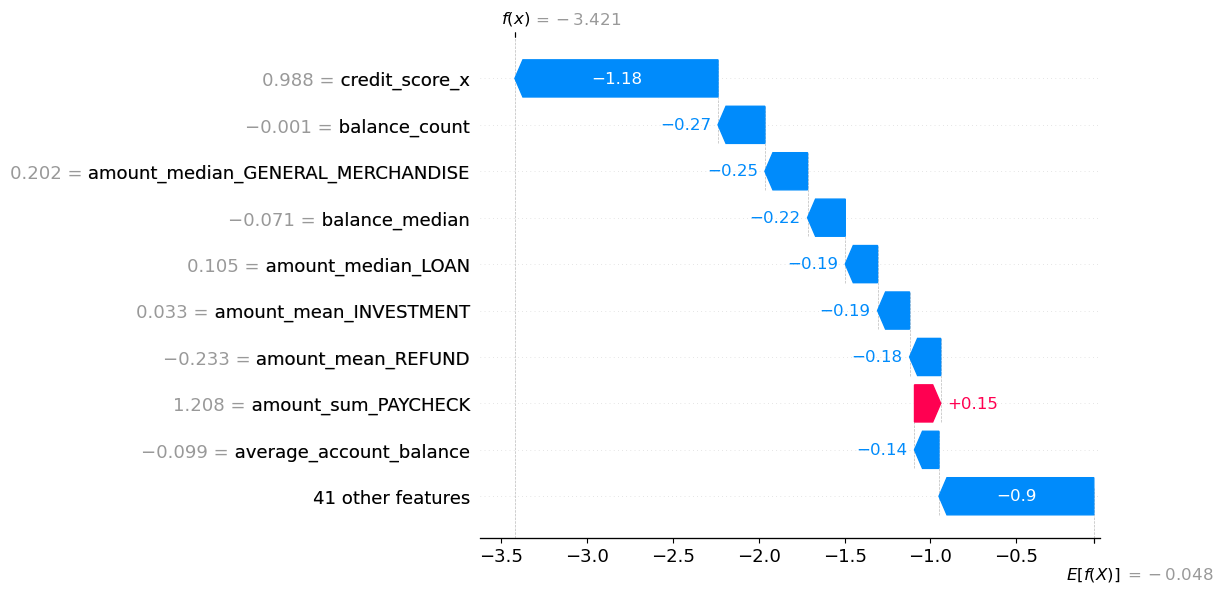

In [18]:
shap.plots.waterfall(shap_values[0])

- Reason codes for default:

In [19]:
scaled_feats['y_true'] = y_test.values
scaled_feats['y_pred'] = y_pred_test

shap_values = explainer(scaled_feats.drop(columns=['y_true', 'y_pred']))

shap_df = pd.DataFrame(shap_values.values, columns=scaled_feats.drop(columns=['y_true', 'y_pred']).columns)

mask = scaled_feats['y_pred'] == 1
shap_df_pred_default = shap_df[mask].reset_index(drop=True)

def get_top_feature_names(shap_row, feature_names, top_n=3):
    top_indices = np.argsort(shap_row)[::-1][:top_n]  
    return [feature_names[i] for i in top_indices]  

top_features_pred_default = shap_df_pred_default.apply(
    lambda row: get_top_feature_names(row, shap_df.columns), axis=1
)

top_features_df = pd.DataFrame(top_features_pred_default.tolist(), columns=['Feature_1', 'Feature_2', 'Feature_3'])
top_features_df

,Feature_1,Feature_2,Feature_3
0,average_account_balance,balance_count,amount_sum_GENERAL_MERCHANDISE
1,credit_score_x,balance_count,balance_median
2,credit_score_x,balance_count,amount_count_GROCERIES
3,average_account_balance,balance_min,amount_sum_GENERAL_MERCHANDISE
4,credit_score_x,balance_count,amount_median_LOAN
...,...,...,...
606,credit_score_x,amount_mean_BANKING_CATCH_ALL,balance_count
607,credit_score_x,average_account_balance,amount_count_GROCERIES
608,balance_cv,average_account_balance,amount_sum_PAYCHECK
609,credit_score_x,average_account_balance,balance_count


In [20]:
reasons = top_features_pred_default.explode().value_counts().reset_index()
reasons.rename(columns={'index':'Reason'}, inplace=True)

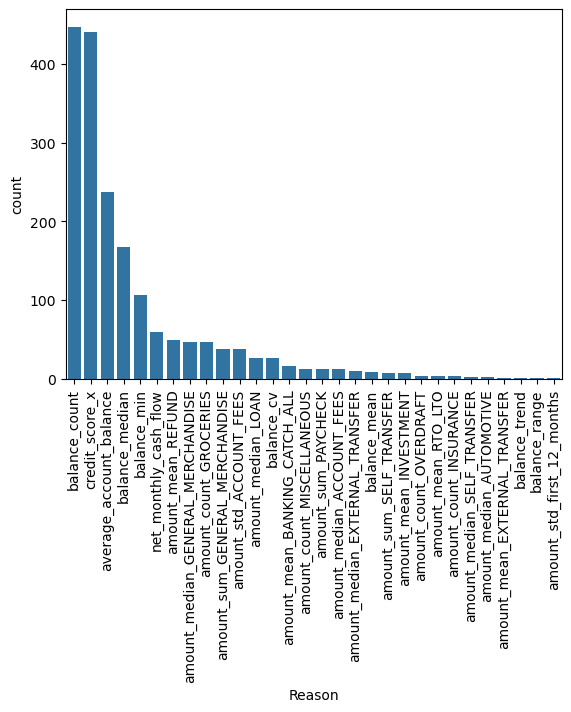

In [21]:
sns.barplot(reasons, x='Reason', y='count');
plt.xticks(rotation=90);

## 6. Heldout Set Predictions

In [48]:
# Heldout Set Predictions with XGBoost and Reason Codes

# 1. Load the original data
print("Loading data...")
consumer_df, account_df, transaction_df = get_data()

# 2. Identify the heldout set (consumers with null DQ_TARGET)
heldout_df = consumer_df[consumer_df['DQ_TARGET'].isna()].copy()
training_df = consumer_df[~consumer_df['DQ_TARGET'].isna()].copy()

print(f"Heldout set size: {len(heldout_df)}")
print(f"Training set size: {len(training_df)}")

# 3. Apply thin file identification to heldout set
print("Identifying thin files...")
enriched_heldout = identify_thin_files(
    transaction_df[transaction_df['prism_consumer_id'].isin(heldout_df['prism_consumer_id'])],
    account_df[account_df['prism_consumer_id'].isin(heldout_df['prism_consumer_id'])],
    heldout_df,
    min_transactions=3,
    min_transaction_months=1,
    min_balance_records=1
)

# Split into thick and thin files
thick_file_ids = enriched_heldout[~enriched_heldout['is_thin_file']]['prism_consumer_id']
thin_file_ids = enriched_heldout[enriched_heldout['is_thin_file']]['prism_consumer_id']

print(f"Thick files: {len(thick_file_ids)}")
print(f"Thin files: {len(thin_file_ids)}")

# 4. Get the reason for thin files
thin_file_reasons = {}
for idx, row in enriched_heldout[enriched_heldout['is_thin_file']].iterrows():
    consumer_id = row['prism_consumer_id']
    if row['insufficient_transactions']:
        thin_file_reasons[consumer_id] = "insufficient_transactions"
    elif row['insufficient_transaction_history']:
        thin_file_reasons[consumer_id] = "insufficient_transaction_history"
    elif row['insufficient_balance_records']:
        thin_file_reasons[consumer_id] = "insufficient_balance_records"
    else:
        thin_file_reasons[consumer_id] = "unknown_reason"

# 5. Define feature functions (excluding credit_score since it's already in consumer_df)
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time_fix,
    balance_over_time
    # credit_score is removed from here since it's already in consumer_df
]

# 6. Calculate features for training data
print("Calculating features for training data...")
train_feature_dataframes = execute_selected_features(
    selected_features, 
    training_df, 
    account_df[account_df['prism_consumer_id'].isin(training_df['prism_consumer_id'])],
    transaction_df[transaction_df['prism_consumer_id'].isin(training_df['prism_consumer_id'])]
)
train_features = merge_features(train_feature_dataframes)

# 7. Merge with consumer data
train_ml_features = training_df.merge(train_features, how="left", on="prism_consumer_id")
train_ml_features = train_ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)

# 8. Define feature columns (with and without credit score)
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'DQ_TARGET']
all_feature_columns = [col for col in train_ml_features.columns if col not in exclude_columns]

# 9. Create feature sets with and without credit score
# Make sure we're using the original credit_score column from consumer_df
with_cs_features = all_feature_columns
without_cs_features = [col for col in all_feature_columns if col != 'credit_score']

print(f"Total features with credit score: {len(with_cs_features)}")
print(f"Total features without credit score: {len(without_cs_features)}")

# 10. Train XGBoost models using the existing train_model function
print("Training XGBoost models...")

# Model with credit score
_, _, model_with_cs, scaler_with_cs = train_model(train_ml_features, with_cs_features, "xgboost")

# Model without credit score
_, _, model_without_cs, scaler_without_cs = train_model(train_ml_features, without_cs_features, "xgboost")

# 11. Calculate features for all consumers in heldout set
print("Calculating features for heldout set...")
heldout_feature_dataframes = execute_selected_features(
    selected_features, 
    heldout_df, 
    account_df[account_df['prism_consumer_id'].isin(heldout_df['prism_consumer_id'])],
    transaction_df[transaction_df['prism_consumer_id'].isin(heldout_df['prism_consumer_id'])]
)
heldout_features = merge_features(heldout_feature_dataframes)

# 12. Merge with consumer data
heldout_ml_features = heldout_df.merge(heldout_features, how="left", on="prism_consumer_id")
heldout_ml_features = heldout_ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)

# 13. Ensure the heldout features match the training features
missing_cols = set(with_cs_features) - set(heldout_ml_features.columns)
for col in missing_cols:
    heldout_ml_features[col] = 0

# 14. Generate predictions for all heldout consumers
print("Generating predictions for heldout set...")
X_heldout_with_cs = heldout_ml_features[with_cs_features]
X_heldout_without_cs = heldout_ml_features[without_cs_features]

X_heldout_scaled_with_cs = scaler_with_cs.transform(X_heldout_with_cs)
X_heldout_scaled_without_cs = scaler_without_cs.transform(X_heldout_without_cs)

# 15. Get probabilities
heldout_probs_with_cs = model_with_cs.predict_proba(X_heldout_scaled_with_cs)[:, 1]
heldout_probs_without_cs = model_without_cs.predict_proba(X_heldout_scaled_without_cs)[:, 1]

# 16. Get SHAP values for reason codes
print("Calculating reason codes...")

# Create SHAP explainers
explainer_with_cs = shap.Explainer(model_with_cs)
explainer_without_cs = shap.Explainer(model_without_cs)

# Calculate SHAP values
shap_values_with_cs = explainer_with_cs(X_heldout_scaled_with_cs)
shap_values_without_cs = explainer_without_cs(X_heldout_scaled_without_cs)

# Create DataFrames with SHAP values
shap_df_with_cs = pd.DataFrame(shap_values_with_cs.values, columns=with_cs_features)
shap_df_without_cs = pd.DataFrame(shap_values_without_cs.values, columns=without_cs_features)

# 17. Function to get top feature names based on SHAP values
def get_top_feature_names(shap_row, feature_names, top_n=3):
    top_indices = np.argsort(np.abs(shap_row))[-top_n:][::-1]  
    return [feature_names[i] for i in top_indices]

# 18. Get top features for each consumer
top_features_with_cs = shap_df_with_cs.apply(
    lambda row: get_top_feature_names(row, with_cs_features), axis=1
)

top_features_without_cs = shap_df_without_cs.apply(
    lambda row: get_top_feature_names(row, without_cs_features), axis=1
)

# 19. Create results dataframe
results = pd.DataFrame({
    'prism_consumer_id': heldout_ml_features['prism_consumer_id'],
    'score_with_cs': heldout_probs_with_cs,
    'score_without_cs': heldout_probs_without_cs
})

# 20. Add reason codes
results['reason1_with_cs'] = [features[0] for features in top_features_with_cs]
results['reason2_with_cs'] = [features[1] for features in top_features_with_cs]
results['reason3_with_cs'] = [features[2] for features in top_features_with_cs]

results['reason1_without_cs'] = [features[0] for features in top_features_without_cs]
results['reason2_without_cs'] = [features[1] for features in top_features_without_cs]
results['reason3_without_cs'] = [features[2] for features in top_features_without_cs]

# 21. For thin files, set scores to NA and update reason codes
for consumer_id in thin_file_ids:
    reason = thin_file_reasons.get(consumer_id, "unknown_reason")
    mask = results['prism_consumer_id'] == consumer_id
    
    # Set scores to NA
    results.loc[mask, ['score_with_cs', 'score_without_cs']] = np.nan
    
    # Set reason codes to the thin file reason
    for col in ['reason1_with_cs', 'reason2_with_cs', 'reason3_with_cs',
               'reason1_without_cs', 'reason2_without_cs', 'reason3_without_cs']:
        results.loc[mask, col] = reason

# 22. Add is_thin_file column
results['is_thin_file'] = results['prism_consumer_id'].isin(thin_file_ids)

# 23. Save results
output_path = '../predictions.csv'
# Remove is_thin_file column before saving
results_to_save = results.drop(columns=['is_thin_file'])
results_to_save.to_csv(output_path, index=False)

# 24. Print summary statistics
print("\nScore Statistics (Thick Files):")
thick_file_stats = results[~results['prism_consumer_id'].isin(thin_file_ids)][['score_with_cs', 'score_without_cs']].describe()
print(thick_file_stats)

# 25. Print most common reason codes
print("\nMost Common Reason Codes (With Credit Score):")
reason_counts = pd.concat([
    results[~results['prism_consumer_id'].isin(thin_file_ids)]['reason1_with_cs'],
    results[~results['prism_consumer_id'].isin(thin_file_ids)]['reason2_with_cs'],
    results[~results['prism_consumer_id'].isin(thin_file_ids)]['reason3_with_cs']
]).value_counts().head(10)
print(reason_counts)

print("\nMost Common Reason Codes (Without Credit Score):")
reason_counts = pd.concat([
    results[~results['prism_consumer_id'].isin(thin_file_ids)]['reason1_without_cs'],
    results[~results['prism_consumer_id'].isin(thin_file_ids)]['reason2_without_cs'],
    results[~results['prism_consumer_id'].isin(thin_file_ids)]['reason3_without_cs']
]).value_counts().head(10)
print(reason_counts)

# 26. Display a sample of the predictions
print("\nSample of predictions:")
results.head()

Loading data...
Data successfully loaded and processed.
Heldout set size: 3000
Training set size: 12000
Identifying thin files...


/Users/qianjin/Desktop/DSC180AB/180B/credit_scoring/src/scripts/utilities.py:1108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['transaction_month'] = transaction_df['posted_date'].dt.to_period('M')


Thick files: 2462
Thin files: 538
Calculating features for training data...

Feature Execution Plan:
- Total feature creation functions: 8
- Unchanged feature creation functions: 8 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for outflow_over_time_fix
- Using cached result for balance_over_time

Total Created Features:  266
Total features with credit score: 267
Total features without credit score: 266
Training XGBoost models...
Calculating features for heldout set...

Feature Execution Plan:
- Total feature creation functions: 8
- Unchanged feature creation functions: 8 (using cached results)

No feature creation functions need 

,prism_consumer_id,score_with_cs,score_without_cs,reason1_with_cs,reason2_with_cs,reason3_with_cs,reason1_without_cs,reason2_without_cs,reason3_without_cs,is_thin_file
0,4000,0.016616,0.018887,credit_score,balance_count,amount_mean_first_6_months,balance_count,amount_mean_first_6_months,balance_min,False
1,4001,0.285695,0.161358,balance_count,amount_mean_GAMBLING,amount_median_GAMBLING,balance_count,amount_mean_GAMBLING,amount_count_EXTERNAL_TRANSFER,False
2,4002,0.009724,0.009246,credit_score,amount_mean_UNEMPLOYMENT_BENEFITS,amount_mean_first_6_months,balance_count,amount_mean_UNEMPLOYMENT_BENEFITS,amount_mean_first_6_months,False
3,4003,0.264668,0.217520,credit_score,average_account_balance,balance_count,balance_count,average_account_balance,amount_median_FITNESS,False
4,4004,0.031849,0.037157,credit_score,balance_count,average_account_balance,balance_count,balance_min,average_account_balance,False


## 7. Reason Codes for Holdout Set:

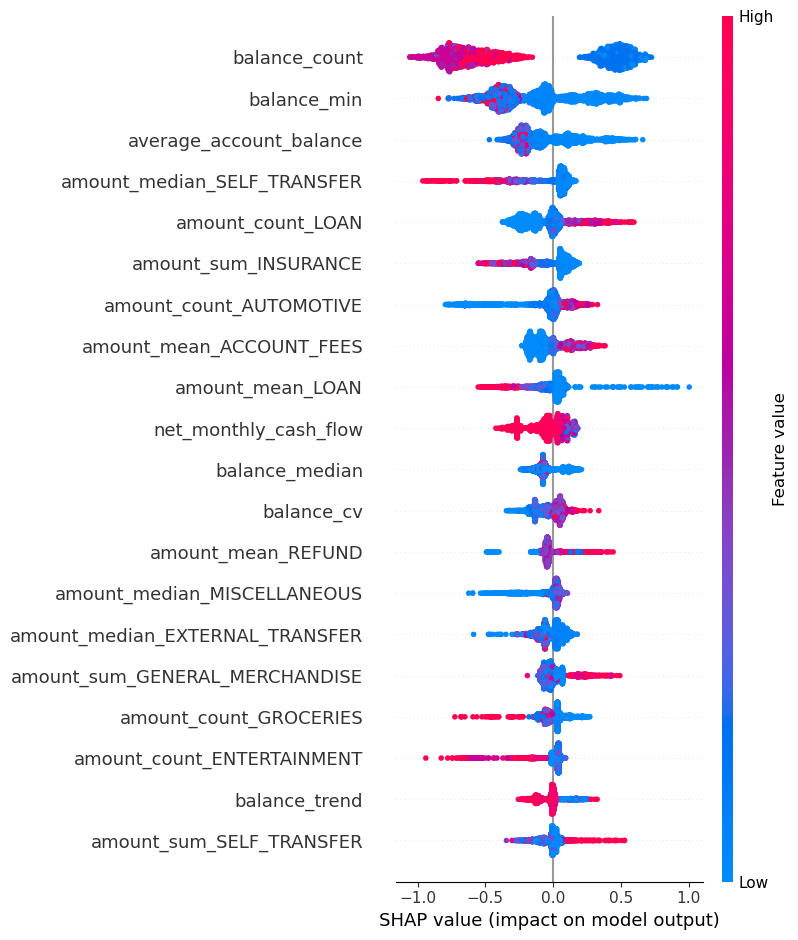

In [27]:
scaled_feats, explainer, shap_values = shap_plots(model, X_thick, X_thick_scaled)

In [28]:
scaled_feats['y_pred'] = thick_file_probs

shap_values = explainer(scaled_feats.drop(columns=['y_pred']))

shap_df = pd.DataFrame(shap_values.values, columns=scaled_feats.drop(columns=['y_pred']).columns)

def get_top_feature_names(shap_row, feature_names, top_n=3):
    top_indices = np.argsort(shap_row)[::-1][:top_n]  
    return [feature_names[i] for i in top_indices]  

top_features_pred_default = shap_df.apply(
    lambda row: get_top_feature_names(row, shap_df.columns), axis=1
)

top_features_df = pd.DataFrame(top_features_pred_default.tolist(), columns=['Feature_1', 'Feature_2', 'Feature_3'])
top_features_df

,Feature_1,Feature_2,Feature_3
0,amount_count_LOAN,amount_sum_INSURANCE,amount_mean_INVESTMENT
1,amount_median_SELF_TRANSFER,amount_median_EXTERNAL_TRANSFER,balance_cv
2,amount_sum_GENERAL_MERCHANDISE,balance_cv,net_monthly_cash_flow
3,amount_count_AUTOMOTIVE,amount_median_BNPL,amount_median_SELF_TRANSFER
4,amount_sum_SELF_TRANSFER,amount_median_MISCELLANEOUS,amount_count_ENTERTAINMENT
...,...,...,...
2457,amount_median_SELF_TRANSFER,amount_median_GENERAL_MERCHANDISE,balance_cv
2458,amount_count_LOAN,amount_sum_GENERAL_MERCHANDISE,amount_count_AUTOMOTIVE
2459,amount_count_LOAN,amount_mean_ACCOUNT_FEES,amount_sum_GENERAL_MERCHANDISE
2460,amount_mean_ACCOUNT_FEES,balance_trend,amount_count_ACCOUNT_FEES


In [29]:
reasons = top_features_pred_default.explode().value_counts().reset_index()
reasons.rename(columns={'index':'Reason'}, inplace=True)

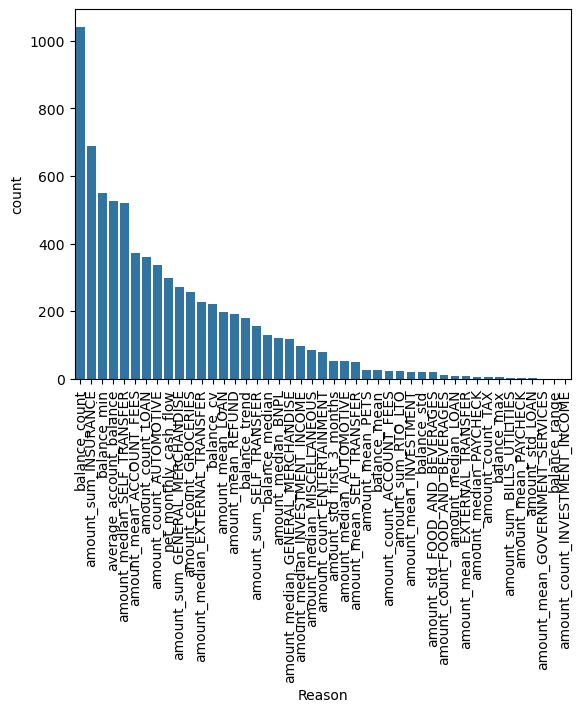

In [30]:
sns.barplot(reasons, x='Reason', y='count');
plt.xticks(rotation=90);

## 8 Cash Score vs Credit Score

In [ ]:
generate_cash_scores(model, scaler, feature_columns, train_df)

In [ ]:
cash_vs_credit_score(model, scaler, feature_columns, test_df, consumer_df)